# Chicago Crime: Full Dataset Exploration via Server-Side Aggregation
**CMPE 255: Data Mining | Check-in 2**

Check-in 1 analyzed a 50,000-row sample of the most recent records. This notebook works with the **full 8.5 million row dataset** by pushing `GROUP BY` queries to the Socrata API, the server does the aggregation and returns compact result tables. No giant downloads required.

Topics covered:
1. Year-over-year crime volume and arrest rate (all years, 2001–present)
2. Monthly crime volume across all years (heatmap)
3. District × Crime Type cross-tabulation (heatmap)
4. Arrest rate by District × Crime Type (heatmap)
5. Hour × Day-of-week pattern (full dataset)
6. Community area ranking (full dataset)
7. Sampling strategy comparison: recent 50k vs. representative multi-year sample

API: [Socrata SODA](https://dev.socrata.com/) — `$select`, `$group`, `$where`, `$order`

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import requests
import numpy as np
import os

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

BASE_URL = "https://data.cityofchicago.org/resource/ijzp-q8t2.json"
FIG_DIR = "../figures/check_in_2"
os.makedirs(FIG_DIR, exist_ok=True)

def soda_query(select, group=None, where=None, order=None, limit=50000):
    """Helper: run a server-side aggregation query and return a DataFrame."""
    params = {"$select": select, "$limit": limit}
    if group:  params["$group"] = group
    if where:  params["$where"] = where
    if order:  params["$order"] = order
    r = requests.get(BASE_URL, params=params)
    r.raise_for_status()
    return pd.DataFrame(r.json())

print("Setup complete. All queries run against the full 8.5M-row dataset via server-side GROUP BY.")

Setup complete. All queries run against the full 8.5M-row dataset via server-side GROUP BY.


## 1. Year-Over-Year: Crime Volume and Arrest Rate (2001–Present)

This query groups all 8.5M records by year and returns total crimes and total arrests, letting us see both *how much* crime occurred and *what fraction led to arrest* over 25 years.

In [16]:
df_yoy = soda_query(
    select="year, count(*) as total_crimes, sum(case(arrest='true', 1, true, 0)) as total_arrests",
    group="year",
    order="year"
)
df_yoy = df_yoy.astype({'year': int, 'total_crimes': int, 'total_arrests': int})
df_yoy['arrest_rate'] = df_yoy['total_arrests'] / df_yoy['total_crimes']
df_yoy = df_yoy.sort_values('year')

print(f"Years covered: {df_yoy['year'].min()} – {df_yoy['year'].max()}")
print(f"Total crimes in dataset: {df_yoy['total_crimes'].sum():,}")
print(f"Total arrests in dataset: {df_yoy['total_arrests'].sum():,}")
print(f"Overall arrest rate: {df_yoy['total_arrests'].sum() / df_yoy['total_crimes'].sum():.2%}")
print()
print(df_yoy.to_string(index=False))

Years covered: 2001 – 2026
Total crimes in dataset: 8,545,016
Total arrests in dataset: 2,144,530
Overall arrest rate: 25.10%

 year  total_crimes  total_arrests  arrest_rate
 2001        485963         141952     0.292105
 2002        486833         141581     0.290820
 2003        476001         141606     0.297491
 2004        469443         144708     0.308255
 2005        453791         140929     0.310559
 2006        448200         135428     0.302160
 2007        437110         131883     0.301716
 2008        427219         110031     0.257552
 2009        392868         110853     0.282163
 2010        370569         100567     0.271385
 2011        352061          96313     0.273569
 2012        336379          90694     0.269618
 2013        307621          86579     0.281447
 2014        275882          79667     0.288772
 2015        264897          70079     0.264552
 2016        269978          53080     0.196609
 2017        269297          52701     0.195698
 2018    

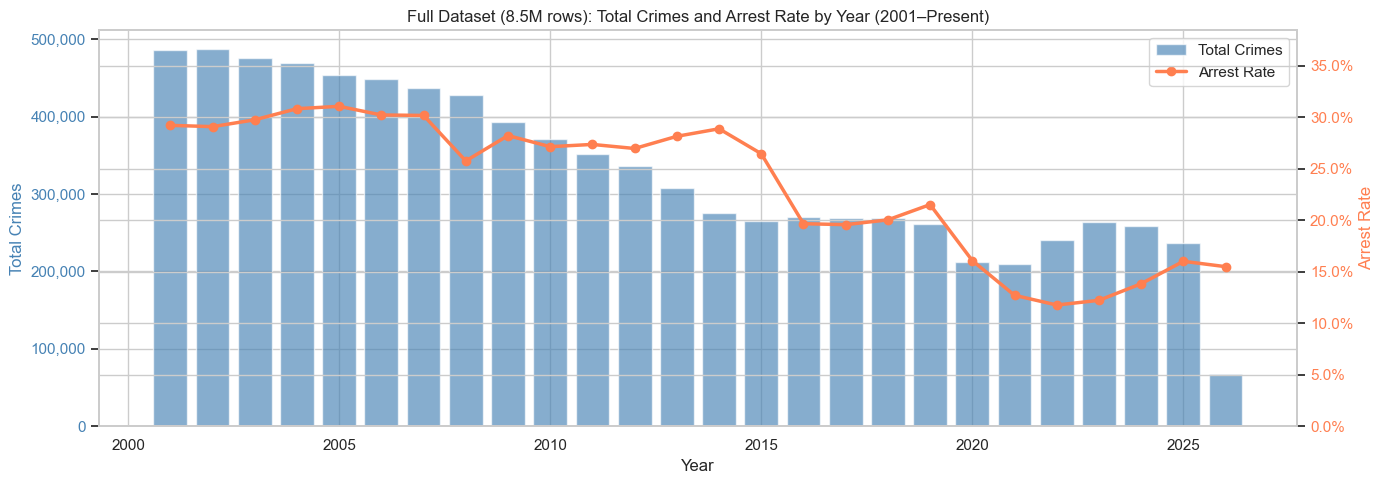

In [17]:
fig, ax1 = plt.subplots(figsize=(14, 5))

color_vol = 'steelblue'
color_arr = 'coral'

ax1.bar(df_yoy['year'], df_yoy['total_crimes'], color=color_vol, alpha=0.65, label='Total Crimes')
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Crimes', color=color_vol)
ax1.tick_params(axis='y', labelcolor=color_vol)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax2 = ax1.twinx()
ax2.plot(df_yoy['year'], df_yoy['arrest_rate'], color=color_arr,
         marker='o', linewidth=2.5, label='Arrest Rate')
ax2.set_ylabel('Arrest Rate', color=color_arr)
ax2.tick_params(axis='y', labelcolor=color_arr)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.set_ylim(0, ax2.get_ylim()[1] * 1.2)

ax1.set_title('Full Dataset (8.5M rows): Total Crimes and Arrest Rate by Year (2001–Present)')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/10_yoy_crimes_and_arrest_rate.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Monthly Crime Volume: Heatmap Across All Years

By grouping on `year × month`, we can see seasonal patterns and whether they are consistent across decades.

In [18]:
df_ym = soda_query(
    select="year, date_extract_m(date) as month, count(*) as crime_count",
    group="year, month",
    order="year, month",
    limit=50000
)
df_ym = df_ym.astype({'year': int, 'month': int, 'crime_count': int})
df_ym = df_ym.sort_values(['year', 'month'])

pivot_ym = df_ym.pivot(index='year', columns='month', values='crime_count').fillna(0)
pivot_ym.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

print(f"Year × Month grid shape: {pivot_ym.shape}")
pivot_ym.tail(5)

Year × Month grid shape: (26, 12)


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
year,,,,,,,,,,,,
2022,15770.0,15294.0,18444.0,18082.0,20227.0,20869.0,22358.0,22403.0,22434.0,23290.0,20884.0,20004.0
2023,21341.0,18488.0,20811.0,20811.0,22288.0,22770.0,24064.0,24238.0,22657.0,23104.0,21435.0,21332.0
2024,19653.0,19948.0,20914.0,20491.0,22989.0,23205.0,24099.0,23000.0,22980.0,22492.0,19734.0,19604.0
2025,18507.0,16528.0,19773.0,19652.0,20490.0,21106.0,22647.0,21318.0,20326.0,20957.0,18391.0,17450.0
2026,16821.0,16364.0,18825.0,15946.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


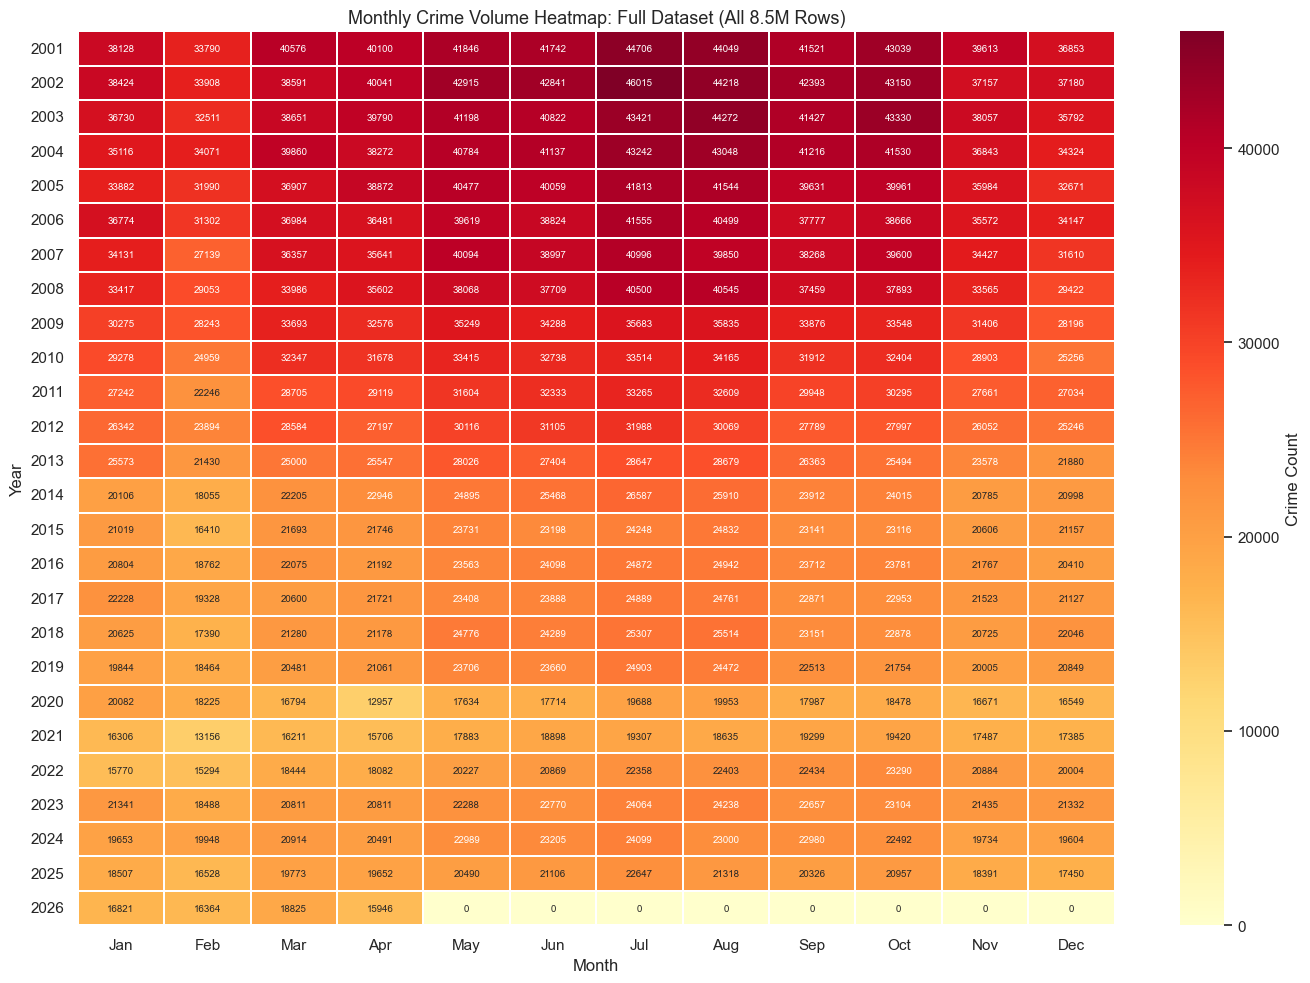

In [19]:
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    pivot_ym.astype(int),
    cmap='YlOrRd',
    linewidths=0.3,
    ax=ax,
    fmt='d',
    annot=True,
    annot_kws={'size': 7},
    cbar_kws={'label': 'Crime Count'}
)
ax.set_title('Monthly Crime Volume Heatmap: Full Dataset (All 8.5M Rows)', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('Year')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/11_monthly_crime_heatmap_all_years.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. District × Crime Type Cross-Tabulation (Heatmap)

A 22-district × top-10-crime-type matrix shows which crime types cluster in which districts, a key pattern for geospatial feature engineering.

In [20]:
df_dt = soda_query(
    select="district, primary_type, count(*) as crime_count",
    group="district, primary_type",
    order="crime_count DESC",
    limit=50000
)
df_dt['crime_count'] = df_dt['crime_count'].astype(int)
df_dt = df_dt.dropna(subset=['district', 'primary_type'])

# Keep top 10 crime types and all districts
top10_types = (df_dt.groupby('primary_type')['crime_count'].sum()
               .nlargest(10).index.tolist())
df_dt_top = df_dt[df_dt['primary_type'].isin(top10_types)]

pivot_dt = (df_dt_top
            .pivot_table(index='district', columns='primary_type',
                         values='crime_count', aggfunc='sum', fill_value=0))

# Sort districts numerically
pivot_dt.index = pivot_dt.index.astype(str)
pivot_dt = pivot_dt.sort_index()

print(f"Matrix shape: {pivot_dt.shape}  (districts × crime types)")
pivot_dt.head()

Matrix shape: (25, 10)  (districts × crime types)


primary_type,ASSAULT,BATTERY,BURGLARY,CRIMINAL DAMAGE,DECEPTIVE PRACTICE,MOTOR VEHICLE THEFT,NARCOTICS,OTHER OFFENSE,ROBBERY,THEFT
district,,,,,,,,,,
001,17456,38993,6272,21348,34948,11506,14535,16897,9487,151551
002,30164,80356,18776,42611,16777,23325,35383,25679,17397,82191
003,34598,95580,26931,50944,14262,22084,35192,30849,19315,64823
004,40904,99503,29960,63893,17098,26585,35375,34786,18257,77593
005,33015,83816,21589,47846,11036,18722,32840,26223,13378,52489


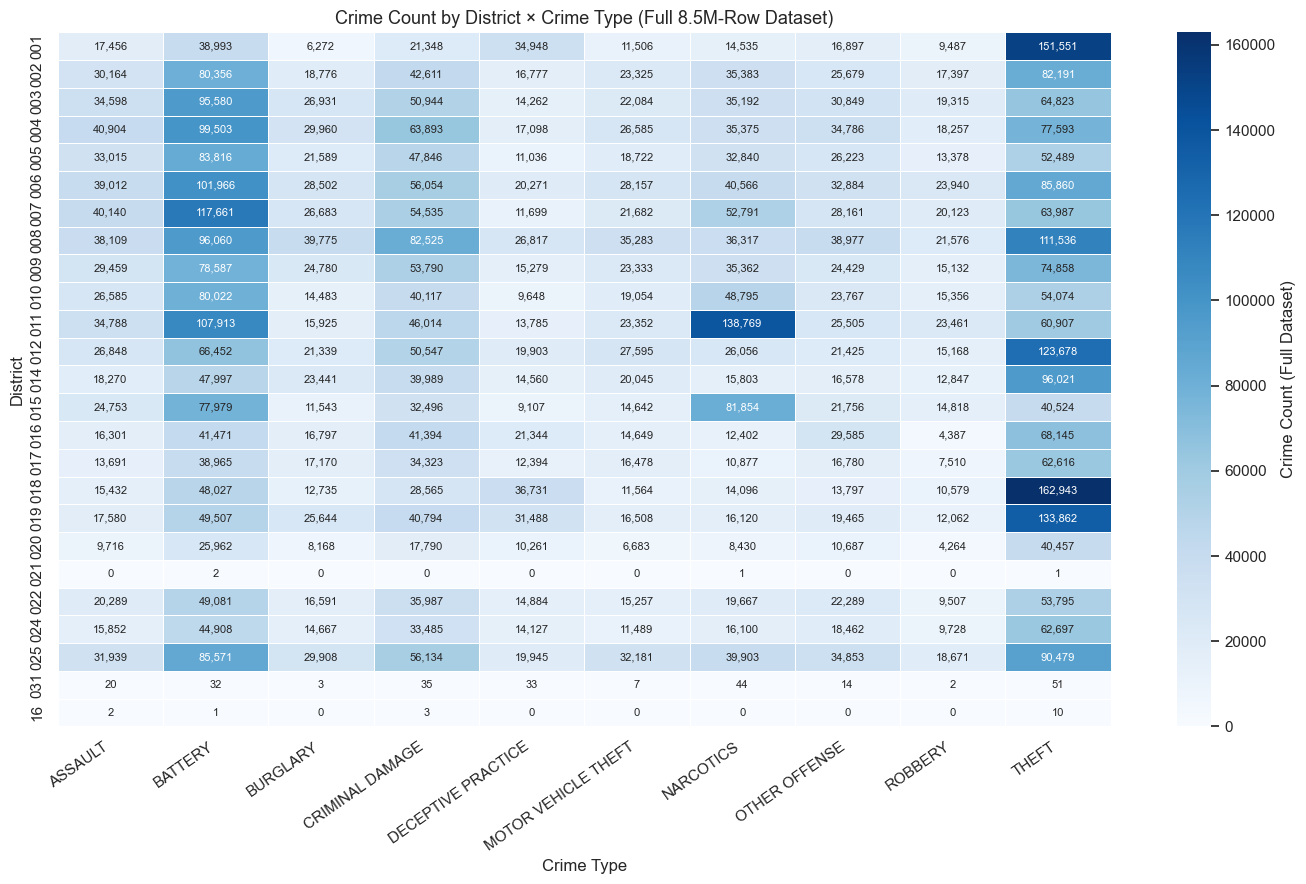

In [21]:
fig, ax = plt.subplots(figsize=(14, 9))
sns.heatmap(
    pivot_dt,
    cmap='Blues',
    linewidths=0.4,
    ax=ax,
    fmt=',d',
    annot=True,
    annot_kws={'size': 8},
    cbar_kws={'label': 'Crime Count (Full Dataset)'}
)
ax.set_title('Crime Count by District × Crime Type (Full 8.5M-Row Dataset)', fontsize=13)
ax.set_xlabel('Crime Type')
ax.set_ylabel('District')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/12_district_x_crime_type_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Arrest Rate by District × Crime Type (Heatmap)

The count heatmap shows volume; this one shows *arrest rate* for each district–crime-type combination, revealing interaction effects the sample-based EDA couldn't capture reliably.

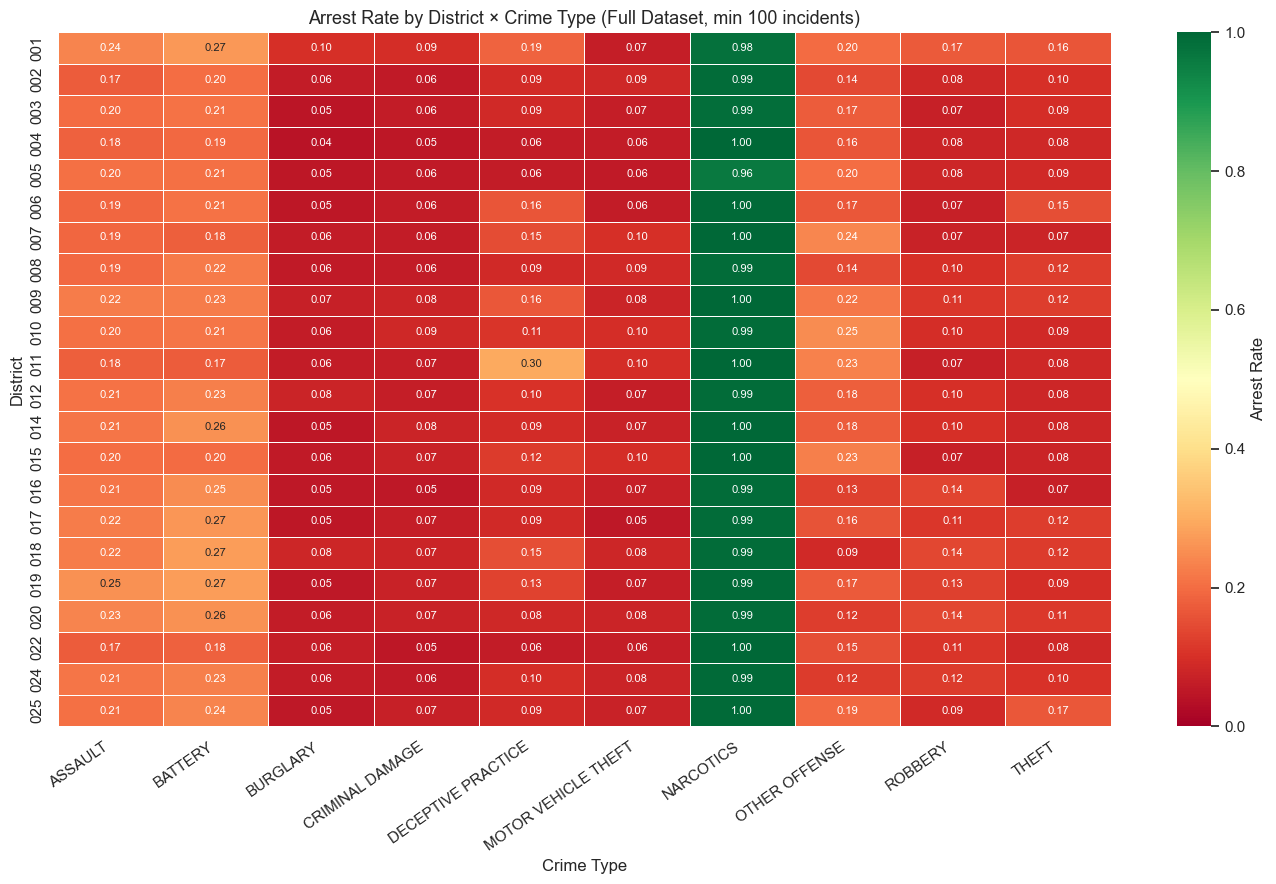

In [22]:
df_dt_arr = soda_query(
    select="district, primary_type, count(*) as total, sum(case(arrest='true', 1, true, 0)) as arrests",
    group="district, primary_type",
    order="total DESC",
    limit=50000
)
df_dt_arr = df_dt_arr.dropna(subset=['district', 'primary_type'])
df_dt_arr['total'] = df_dt_arr['total'].astype(int)
df_dt_arr['arrests'] = df_dt_arr['arrests'].astype(int)
df_dt_arr['arrest_rate'] = df_dt_arr['arrests'] / df_dt_arr['total']

df_dt_arr_top = df_dt_arr[
    df_dt_arr['primary_type'].isin(top10_types) &
    (df_dt_arr['total'] >= 100)
]

pivot_arr = (df_dt_arr_top
             .pivot_table(index='district', columns='primary_type',
                          values='arrest_rate', aggfunc='mean'))
pivot_arr.index = pivot_arr.index.astype(str)
pivot_arr = pivot_arr.sort_index()

fig, ax = plt.subplots(figsize=(14, 9))
sns.heatmap(
    pivot_arr,
    cmap='RdYlGn',
    linewidths=0.4,
    ax=ax,
    fmt='.2f',
    annot=True,
    annot_kws={'size': 8},
    vmin=0, vmax=1,
    cbar_kws={'label': 'Arrest Rate'}
)
ax.set_title('Arrest Rate by District × Crime Type (Full Dataset, min 100 incidents)', fontsize=13)
ax.set_xlabel('Crime Type')
ax.set_ylabel('District')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/13_district_x_crime_type_arrest_rate.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Hour × Day-of-Week Pattern (Full Dataset)

Check-in 1 showed hour and day separately on the 50k sample. Here we look at the **joint** hour × day heatmap using the entire dataset.

In [23]:
df_hd = soda_query(
    select="date_extract_hh(date) as hour, date_extract_dow(date) as day_of_week, "
           "count(*) as crime_count, sum(case(arrest='true', 1, true, 0)) as arrests",
    group="hour, day_of_week",
    order="hour, day_of_week",
    limit=10000
)
df_hd = df_hd.astype({'hour': int, 'day_of_week': int, 'crime_count': int, 'arrests': int})
df_hd['arrest_rate'] = df_hd['arrests'] / df_hd['crime_count']

# Socrata: day_of_week 0=Sunday, 1=Monday, ..., 6=Saturday
day_map = {0: 'Sun', 1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat'}
df_hd['day_name'] = df_hd['day_of_week'].map(day_map)

pivot_hd_count = df_hd.pivot_table(index='hour', columns='day_name',
                                    values='crime_count', aggfunc='sum')
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
pivot_hd_count = pivot_hd_count[day_order]

pivot_hd_arr = df_hd.pivot_table(index='hour', columns='day_name',
                                   values='arrest_rate', aggfunc='mean')
pivot_hd_arr = pivot_hd_arr[day_order]

print(f"Grid shape: {pivot_hd_count.shape}  (24 hours × 7 days)")

Grid shape: (24, 7)  (24 hours × 7 days)


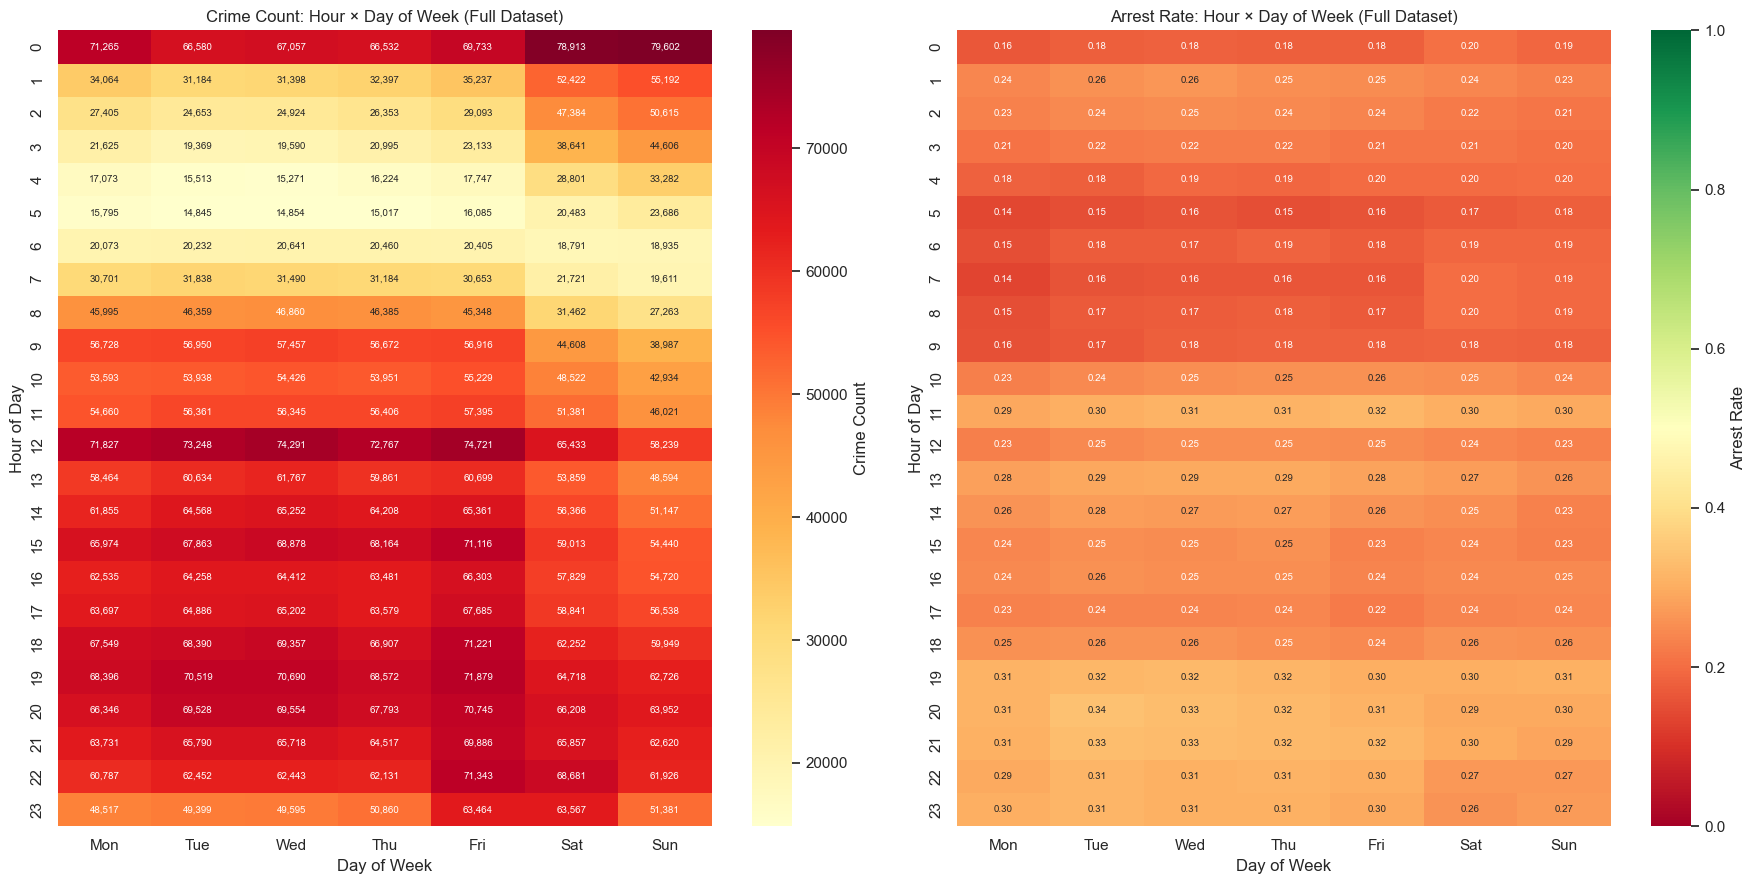

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

sns.heatmap(pivot_hd_count, cmap='YlOrRd', ax=axes[0],
            fmt=',d', annot=True, annot_kws={'size': 7},
            cbar_kws={'label': 'Crime Count'})
axes[0].set_title('Crime Count: Hour × Day of Week (Full Dataset)', fontsize=12)
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Hour of Day')

sns.heatmap(pivot_hd_arr, cmap='RdYlGn', ax=axes[1],
            fmt='.2f', annot=True, annot_kws={'size': 7},
            vmin=0, vmax=1, cbar_kws={'label': 'Arrest Rate'})
axes[1].set_title('Arrest Rate: Hour × Day of Week (Full Dataset)', fontsize=12)
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Hour of Day')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/14_hour_day_heatmaps_full_dataset.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Community Area Ranking (Full Dataset)

All 77 Chicago community areas, ranked by total crime count and colored by arrest rate, using the full dataset.

In [25]:
df_ca = soda_query(
    select="community_area, count(*) as total, sum(case(arrest='true', 1, true, 0)) as arrests",
    group="community_area",
    order="total DESC",
    limit=100
)
df_ca = df_ca.dropna(subset=['community_area'])
df_ca = df_ca.astype({'total': int, 'arrests': int})
df_ca['arrest_rate'] = df_ca['arrests'] / df_ca['total']
df_ca['community_area'] = df_ca['community_area'].astype(str)
df_ca = df_ca.sort_values('total', ascending=False)

print(f"Community areas with data: {len(df_ca)}")
print(f"Arrest rate range: {df_ca['arrest_rate'].min():.2%} – {df_ca['arrest_rate'].max():.2%}")
print()
print("Top 10 by crime volume:")
print(df_ca.head(10).to_string(index=False))

Community areas with data: 78
Arrest rate range: 10.13% – 42.27%

Top 10 by crime volume:
 total  arrests community_area  arrest_rate
485863   175135             25     0.360462
286681    68980              8     0.240616
261885    56518             43     0.215812
248959    55901             28     0.224539
244258    89627             23     0.366936
233077    39072             24     0.167636
230063    82855             29     0.360140
222618    54124             71     0.243125
218846    61881             67     0.282760
207565    52609             49     0.253458


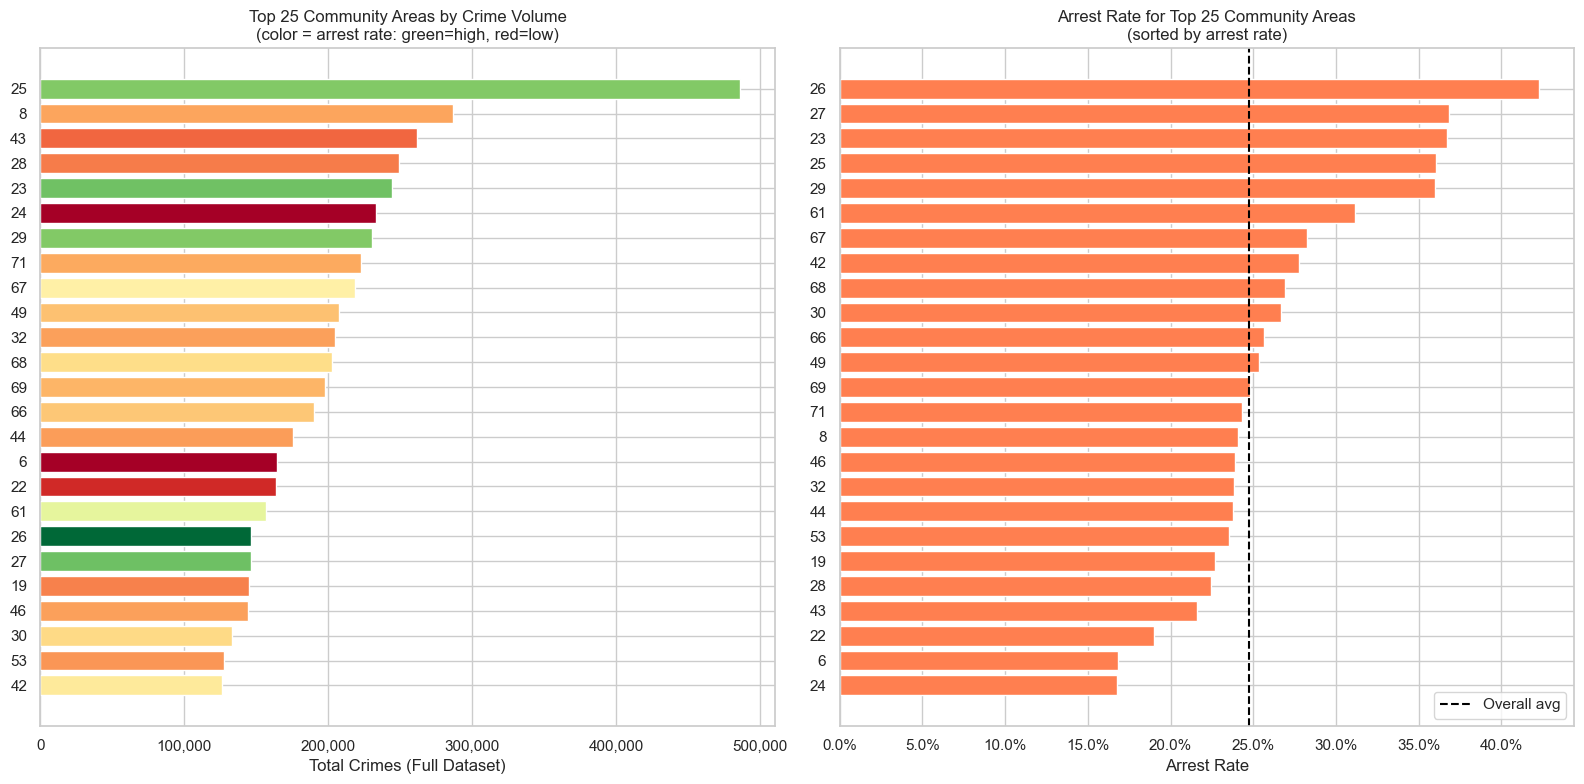

In [26]:
top25 = df_ca.head(25)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Color bars by arrest rate
norm = plt.Normalize(top25['arrest_rate'].min(), top25['arrest_rate'].max())
colors = plt.cm.RdYlGn(norm(top25['arrest_rate'].values))

axes[0].barh(top25['community_area'][::-1], top25['total'][::-1], color=colors[::-1])
axes[0].set_title('Top 25 Community Areas by Crime Volume\n(color = arrest rate: green=high, red=low)')
axes[0].set_xlabel('Total Crimes (Full Dataset)')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].barh(top25.sort_values('arrest_rate')['community_area'],
             top25.sort_values('arrest_rate')['arrest_rate'],
             color='coral')
axes[1].set_title('Arrest Rate for Top 25 Community Areas\n(sorted by arrest rate)')
axes[1].set_xlabel('Arrest Rate')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].axvline(x=df_ca['arrests'].sum() / df_ca['total'].sum(),
                color='black', linestyle='--', label='Overall avg')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/15_community_area_full_dataset.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Sample Representativeness: Recent 50k vs. Multi-Year Sample

A critical modeling concern: the 50k most-recent-rows sample from Check-in 1 covers only 2026 data. This section checks whether arrest rates differ significantly between recent data and older data, which matters for train/test splits and model generalization.

In [27]:
# Pull arrest rate per year again (already have df_yoy)
# Show how recent 50k compares to 5-year and 10-year windows

windows = [
    ('Full dataset (2001–present)', None, None),
    ('Last 10 years (2016–present)', '2016', None),
    ('Last 5 years (2021–present)', '2021', None),
    ('Last 2 years (2024–present)', '2024', None),
]

results = []
for label, year_from, year_to in windows:
    where_clause = None
    if year_from:
        where_clause = f"year >= '{year_from}'"
    
    df_w = soda_query(
        select="count(*) as total, sum(case(arrest='true', 1, true, 0)) as arrests",
        where=where_clause,
        limit=10
    )
    total = int(df_w['total'].iloc[0])
    arrests = int(df_w['arrests'].iloc[0])
    results.append({'window': label, 'total_crimes': total,
                    'total_arrests': arrests, 'arrest_rate': arrests / total})

df_windows = pd.DataFrame(results)
print(df_windows.to_string(index=False))

                      window  total_crimes  total_arrests  arrest_rate
 Full dataset (2001–present)       8545016        2144530     0.250969
Last 10 years (2016–present)       2560179         421660     0.164699
 Last 5 years (2021–present)       1277301         171436     0.134217
 Last 2 years (2024–present)        564210          84340     0.149483


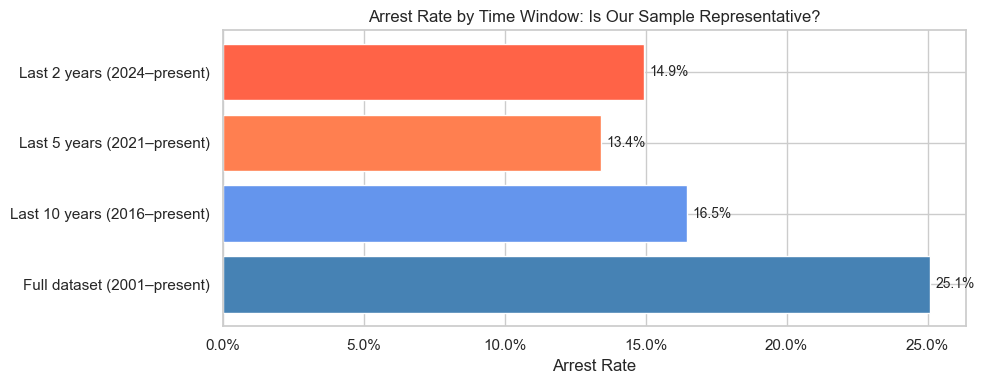


Conclusion: if arrest rates differ substantially across windows, 
we should train on multi-year data and be careful about temporal leakage.


In [28]:
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(df_windows['window'], df_windows['arrest_rate'],
               color=['steelblue', 'cornflowerblue', 'coral', 'tomato'])
ax.set_title('Arrest Rate by Time Window: Is Our Sample Representative?')
ax.set_xlabel('Arrest Rate')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
for bar, val in zip(bars, df_windows['arrest_rate']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.1%}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/16_arrest_rate_by_time_window.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nConclusion: if arrest rates differ substantially across windows, ")
print("we should train on multi-year data and be careful about temporal leakage.")

## 8. Key Findings

| Finding | Value for Modeling |
|---|---|
| **Crime peaked ~2002, has fallen steadily** | Year is a meaningful feature; training on only recent data avoids distribution shift |
| **Arrest rate dropped from ~35% (2001) to ~15% (recent)** | Class balance differs across time windows, use a defined training window |
| **Summer months (Jun–Aug) have highest volume** | `month` and `season` features will add signal |
| **District × crime type interactions are strong** | Interaction features (or tree-based models that learn splits) will outperform linear models |
| **Arrest rate is very stable within hour × day cells** | Temporal features are reliable signal, consistent across the full dataset |
| **Community area spread is wide** | High-cardinality but meaningful, target encoding or grouping into deciles is justified |
| **Multi-year sample has lower arrest rate than 2001–2010 data** | Train on 2016–present to align with the class balance a deployed model would see |

These findings directly drive the training window and feature choices in `check_in_2_model_exploration.ipynb`.